# Amazon Delivery Operations Analysis

This notebook uses a public Kaggle dataset to show a sample operations analysis. It starts with a broad business problem, defines KPIs, tests hypotheses, and ends with a clear next step. This analysis was not requested by Amazon and does not describe Amazon's real operations.

## 1. Business Problem

The team found that some deliveries take too long. Because operations resources are limited, the team needs to find the factors linked to longer delivery times and decide which part of the process to investigate first.

## 2. Analytical Question

The broad business problem is split into five specific questions:

1. **Where are longer deliveries concentrated?** Compare delivery time across Area, Traffic, Pickup Period, Distance, Weather, and Category.
2. **Are the group differences large enough to matter?** Check sample size, mean, median, IQR, and long-duration rate instead of using statistical significance alone.
3. **Can known factors explain the largest area difference?** For Semi-Urban deliveries, check Distance, Traffic, Pickup Period, and Category step by step.
4. **Which relationships remain after including other observed factors?** Use a multivariable model to check whether the links with Area, Traffic, Pickup Period, and Distance remain stable.
5. **What should the team investigate first?** Consider the size of the difference, sample size, result stability, and whether the team can take action.

This analysis ranks follow-up work. It does not prove cause and effect. The data is a static observational dataset and does not include possible explanations such as route design, order volume, agent availability, promised delivery time, or pickup waiting time.

## 3. KPI

**Main KPI: `Delivery_Time`**

This measures the time for each delivery in minutes. Group comparisons use the mean, median, IQR, and full distribution. This avoids relying on the mean alone.

**Supporting metric: Long-Duration Delivery Rate**

A delivery above the 75th percentile of `Delivery_Time` is temporarily called a long-duration delivery. This metric is used to compare groups. The dataset does not include an SLA or promised ETA, so this cutoff is not a late-delivery standard.

## 4. Data Quality Summary

The full cleaning logic is in `src/data_preparation.py`. This notebook only shows the quality issues that affect the analysis. The raw data is not overwritten, and missing values are not imputed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython import get_ipython
from IPython.display import display
from scipy.stats import kruskal, norm, spearmanr

from src.data_preparation import (
    add_analysis_features,
    audit_raw_data,
    clean_delivery_data,
)

if get_ipython() is not None:
    get_ipython().run_line_magic("matplotlib", "inline")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

raw_df = pd.read_csv("raw/amazon_delivery.csv")
raw_audit, raw_missing = audit_raw_data(raw_df)
cleaned_df, cleaning_log = clean_delivery_data(raw_df)
df, long_delivery_threshold, feature_quality = add_analysis_features(cleaned_df)

In [2]:
data_quality_summary = pd.DataFrame([
    ["Data size", f"{len(raw_df):,} rows, {raw_df.shape[1]} columns", "Keep raw data and clean a copy"],
    ["Duplicate Order_ID", int(raw_df["Order_ID"].duplicated().sum()), "No duplicate IDs need to be removed"],
    ["Native missing values", "Rating 54; Weather 91", "Exclude only when a field is required"],
    ["Text placeholders for missing values", int(cleaning_log["Text placeholders converted to missing"]), "Convert to real missing values"],
    ["Rating outside 1-5", int(cleaning_log["Invalid ratings converted to missing"]), "Set Rating to missing and keep the delivery"],
    ["Pickup_Time across midnight", int(cleaning_log["Pickup timestamps rolled into the next day"]), "Add one day to the pickup timestamp"],
    ["Zero-origin coordinates", int(cleaning_log["Zero-origin coordinate records flagged"]), "Keep the delivery but exclude it from distance analysis"],
    ["Coordinate sign mismatch", int(cleaning_log["Coordinate sign-mismatch records flagged"]), "Keep the delivery but exclude it from distance analysis"],
    ["Cleaned data", f"{len(df):,} rows", "Do not remove a full row for a local field issue"],
    ["Long-duration cutoff", f"> {long_delivery_threshold:.0f} minutes", "Analysis cutoff, not an SLA"],
], columns=["Quality issue", "Finding", "Action"])

display(data_quality_summary)

,Quality issue,Finding,Action
0,Data size,"43,739 rows, 16 columns",Keep raw data and clean a copy
1,Duplicate Order_ID,0,No duplicate IDs need to be removed
2,Native missing values,Rating 54; Weather 91,Exclude only when a field is required
3,Text placeholders for missing values,182,Convert to real missing values
4,Rating outside 1-5,53,Set Rating to missing and keep the delivery
5,Pickup_Time across midnight,828,Add one day to the pickup timestamp
6,Zero-origin coordinates,3505,Keep the delivery but exclude it from distance...
7,Coordinate sign mismatch,188,Keep the delivery but exclude it from distance...
8,Cleaned data,"43,739 rows",Do not remove a full row for a local field issue
9,Long-duration cutoff,> 160 minutes,"Analysis cutoff, not an SLA"


All 43,739 delivery records remain after cleaning. Missing Rating, Weather, or Traffic values do not cause a full row to be removed. Each analysis only excludes records that are missing a required field. Distance analysis uses the 40,046 records that passed the coordinate quality checks.

### Delivery Time Distribution

The chart below shows the full distribution of the main KPI, `Delivery_Time`, together with the median and the long-duration cutoff used in this analysis.

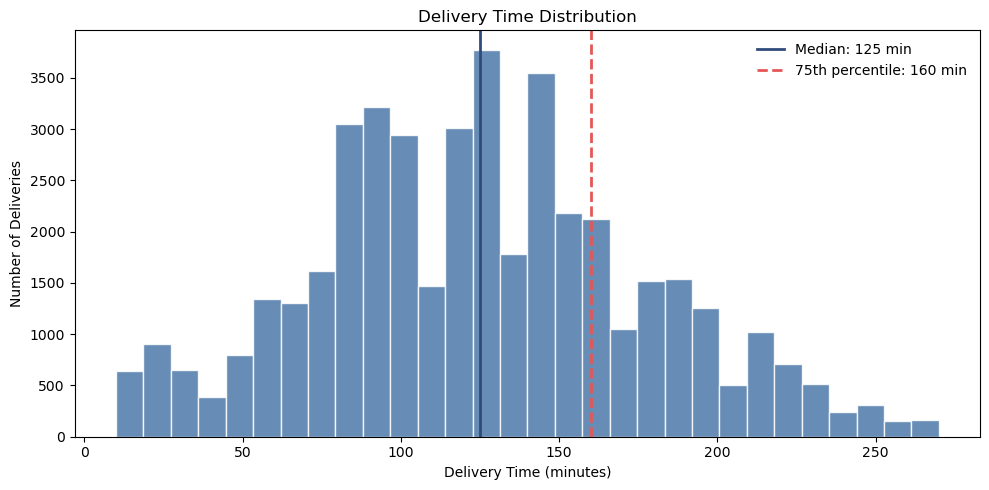

In [3]:
# Show the KPI distribution and the analytical threshold.
fig, axis = plt.subplots(figsize=(10, 5))
axis.hist(df["Delivery_Time"], bins=30, color="#4C78A8", alpha=0.85, edgecolor="white")
axis.axvline(df["Delivery_Time"].median(), color="#2F4B7C", linewidth=2, label=f"Median: {df['Delivery_Time'].median():.0f} min")
axis.axvline(long_delivery_threshold, color="#E45756", linewidth=2, linestyle="--", label=f"75th percentile: {long_delivery_threshold:.0f} min")
axis.set_title("Delivery Time Distribution")
axis.set_xlabel("Delivery Time (minutes)")
axis.set_ylabel("Number of Deliveries")
axis.legend(frameon=False)
plt.tight_layout()
plt.show()

The median `Delivery_Time` is 125 minutes, and the 75th percentile is 160 minutes. This analysis temporarily labels records above 160 minutes as long-duration deliveries so that groups can be compared. This is not an official SLA or late-delivery cutoff.

## 5. Hypothesis Framework

| Hypothesis | Possible mechanism | Fields used | Possible action if supported |
|---|---|---|---|
| H1: Longer distance may mean longer delivery time | Travel time rises with distance | Distance, Delivery Time | Review route design and route assignment |
| H2: Afternoon or evening deliveries may be slower | Traffic, demand, or available capacity may differ | Pickup Period, Traffic, Delivery Time | Review capacity by time period and dispatch rules |
| H3: Semi-Urban deliveries may be slower | Traffic mix, routes, or local processes may differ | Area, Traffic, Distance, Delivery Time | Start an area-level process review |
| H4: Product category may affect delivery time | Pickup handling may use a different process | Category, Delivery Time | Check whether categories use different processes |
| H5: Weather may affect delivery time | Road conditions and travel speed may change | Weather, Delivery Time | Use weather as a planning or model adjustment factor |

Operations decisions can partly change capacity by Pickup Period and route-related Distance. Area and Traffic help identify where the team should focus. Weather and Category mainly provide context and help adjust comparisons, but the team can still improve how it responds to these conditions.

## 6. Key Group Comparisons

### 6.1 Screen the candidate grouping factors

This step compares five grouping factors: `Area`, `Traffic`, `Pickup Period`, `Category`, and `Weather`. `Distance` is continuous, so it is checked separately in the next section.

The screening table uses `usable_records` and `groups` to show the data behind each result. `mean_gap_minutes` is the difference in average delivery time between the highest and lowest group. `median_gap_minutes` is the difference in a typical delivery. `long_duration_rate_gap_pp` is the percentage-point difference in the long-duration rate. `eta_squared` shows how strongly each factor is related to the overall variation in Delivery Time. The Kruskal-Wallis test checks whether group distributions differ, but the sample is large, so the decision does not rely on the p-value alone.

### 6.2 Delivery time distributions for priority factors

Category has the largest difference, but this result is mainly caused by Grocery deliveries, which are much shorter. Weather cannot be controlled directly. The main charts therefore focus on `Area`, `Traffic`, and `Pickup Period`, which are more useful for finding an operations setting to investigate. Category and Weather remain in the multivariable model as adjustment factors.

In each boxplot, the center line is the median. The box runs from the 25th to the 75th percentile, or IQR. The lines outside the box show the main range beyond the IQR. Extreme points are hidden so the main distribution is easier to read. The `n` below each group is its sample size. All three charts use the same y-axis.

In [4]:
def summarize_groups(data, factor):
    # Apply consistent descriptive metrics to each categorical factor.
    subset = data.dropna(subset=[factor, "Delivery_Time"])
    summary = (
        subset.groupby(factor, observed=True)
        .agg(
            sample_size=("Delivery_Time", "size"),
            mean_minutes=("Delivery_Time", "mean"),
            median_minutes=("Delivery_Time", "median"),
            q1_minutes=("Delivery_Time", lambda values: values.quantile(0.25)),
            q3_minutes=("Delivery_Time", lambda values: values.quantile(0.75)),
            long_duration_rate=("Long_Duration_Delivery", "mean"),
        )
        .sort_values("median_minutes", ascending=False)
    )
    summary["long_duration_rate"] *= 100
    return summary


def categorical_screen(data, factor):
    # Combine statistical significance with a practical effect-size summary.
    subset = data.dropna(subset=[factor, "Delivery_Time"])
    grouped = list(subset.groupby(factor, observed=True))
    test_result = kruskal(*[group["Delivery_Time"].to_numpy() for _, group in grouped])
    grand_mean = subset["Delivery_Time"].mean()
    between_group_ss = sum(
        len(group) * (group["Delivery_Time"].mean() - grand_mean) ** 2
        for _, group in grouped
    )
    total_ss = ((subset["Delivery_Time"] - grand_mean) ** 2).sum()
    summary = summarize_groups(data, factor)
    return {
        "factor": factor,
        "usable_records": len(subset),
        "groups": len(grouped),
        "mean_gap_minutes": summary["mean_minutes"].max() - summary["mean_minutes"].min(),
        "median_gap_minutes": summary["median_minutes"].max() - summary["median_minutes"].min(),
        "long_duration_rate_gap_pp": summary["long_duration_rate"].max() - summary["long_duration_rate"].min(),
        "eta_squared": between_group_ss / total_ss,
        "p_value": test_result.pvalue,
    }


categorical_factors = ["Area", "Traffic", "Pickup_Period", "Weather", "Category"]
group_summaries = {factor: summarize_groups(df, factor) for factor in categorical_factors}
screening_results = pd.DataFrame([
    categorical_screen(df, factor) for factor in categorical_factors
]).sort_values("eta_squared", ascending=False)
screening_results["p_value"] = screening_results["p_value"].map(
    lambda value: "< 0.001" if value < 0.001 else f"{value:.3f}"
)

display(screening_results.round(3))

,factor,usable_records,groups,mean_gap_minutes,median_gap_minutes,long_duration_rate_gap_pp,eta_squared,p_value
4,Category,43739,16,106.36,104.00,26.15,0.24,< 0.001
1,Traffic,43648,4,46.40,50.00,34.97,0.13,< 0.001
2,Pickup_Period,43739,4,32.62,35.00,23.47,0.06,< 0.001
3,Weather,43648,6,34.62,40.00,26.21,0.05,< 0.001
0,Area,43739,4,134.09,145.00,83.31,0.05,< 0.001


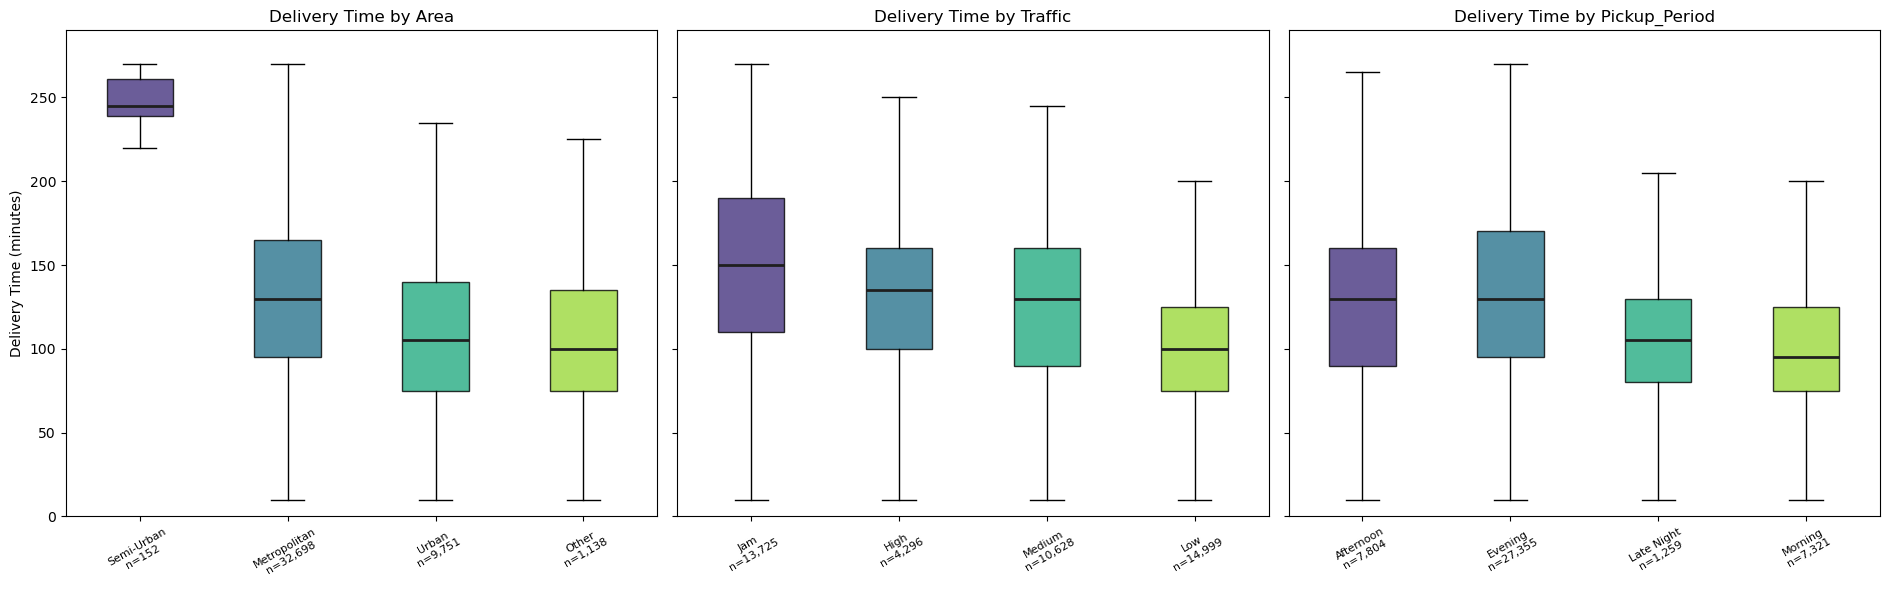

In [5]:
key_factors = ["Area", "Traffic", "Pickup_Period"]
fig, axes = plt.subplots(1, 3, figsize=(19, 6), sharey=True)

for axis, factor in zip(axes, key_factors):
    # Boxplots show the median, IQR, and wider distribution together.
    summary = group_summaries[factor]
    levels = summary.index.tolist()
    distributions = [
        df.loc[df[factor].eq(level), "Delivery_Time"].dropna().to_numpy()
        for level in levels
    ]
    labels = [f"{level}\nn={int(summary.loc[level, 'sample_size']):,}" for level in levels]
    boxplot = axis.boxplot(
        distributions,
        tick_labels=labels,
        showfliers=False,
        patch_artist=True,
        medianprops={"color": "#1F1F1F", "linewidth": 2},
    )
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(levels)))
    for box, color in zip(boxplot["boxes"], colors):
        box.set_facecolor(color)
        box.set_alpha(0.8)
    axis.set_title(f"Delivery Time by {factor}")
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=30, labelsize=8)

axes[0].set_ylabel("Delivery Time (minutes)")
axes[0].set_ylim(0, 290)

plt.tight_layout()
plt.show()

### How to read the charts

- **Area:** Semi-Urban has only 152 records, but its median delivery time is about 245 minutes and about 94.7% are long-duration deliveries.
- **Traffic:** Jam has a median of about 150 minutes, compared with about 100 minutes for Low Traffic. Their long-duration rates are about 41.0% and 6.0%.
- **Pickup Period:** Morning has a median of about 95 minutes, compared with about 130 minutes for Evening. The long-duration rate rises from about 5.2% to 28.7%.

## 7. Semi-Urban Drill-down

### 7.1 Analysis scope

There are 152 Semi-Urban delivery records. All 152 can be used for Area, Traffic, Pickup Period, and Delivery Time comparisons. However, 14 records have Store coordinates of `(0, 0)`, so their distance cannot be calculated reliably. The distance table therefore uses the other 138 records. These 14 records are excluded only from distance analysis.

### 7.2 How to read the charts

- The left chart compares the Traffic mix inside each Area. It checks whether Semi-Urban deliveries are unusually concentrated in heavy traffic.
- The middle chart compares the Pickup Period mix inside each Area. It checks whether Semi-Urban deliveries are concentrated in one time period.
- The right chart keeps only records where Traffic equals Jam, then compares median delivery time across Areas. This checks whether Traffic mix is enough to explain the Area difference.

This step does not prove a cause. It checks whether Distance, Traffic, or Pickup Period can fully explain the unusually long Semi-Urban delivery times.

Distance vs. Delivery Time — Spearman rho: 0.285, p-value < 0.001


,valid_distance_records,median_distance_km,median_delivery_minutes
Area,,,
Semi-Urban,138,12.46,245.00
Metropolitan,29986,9.31,130.00
Other,1048,9.06,100.00
Urban,8874,7.79,105.00


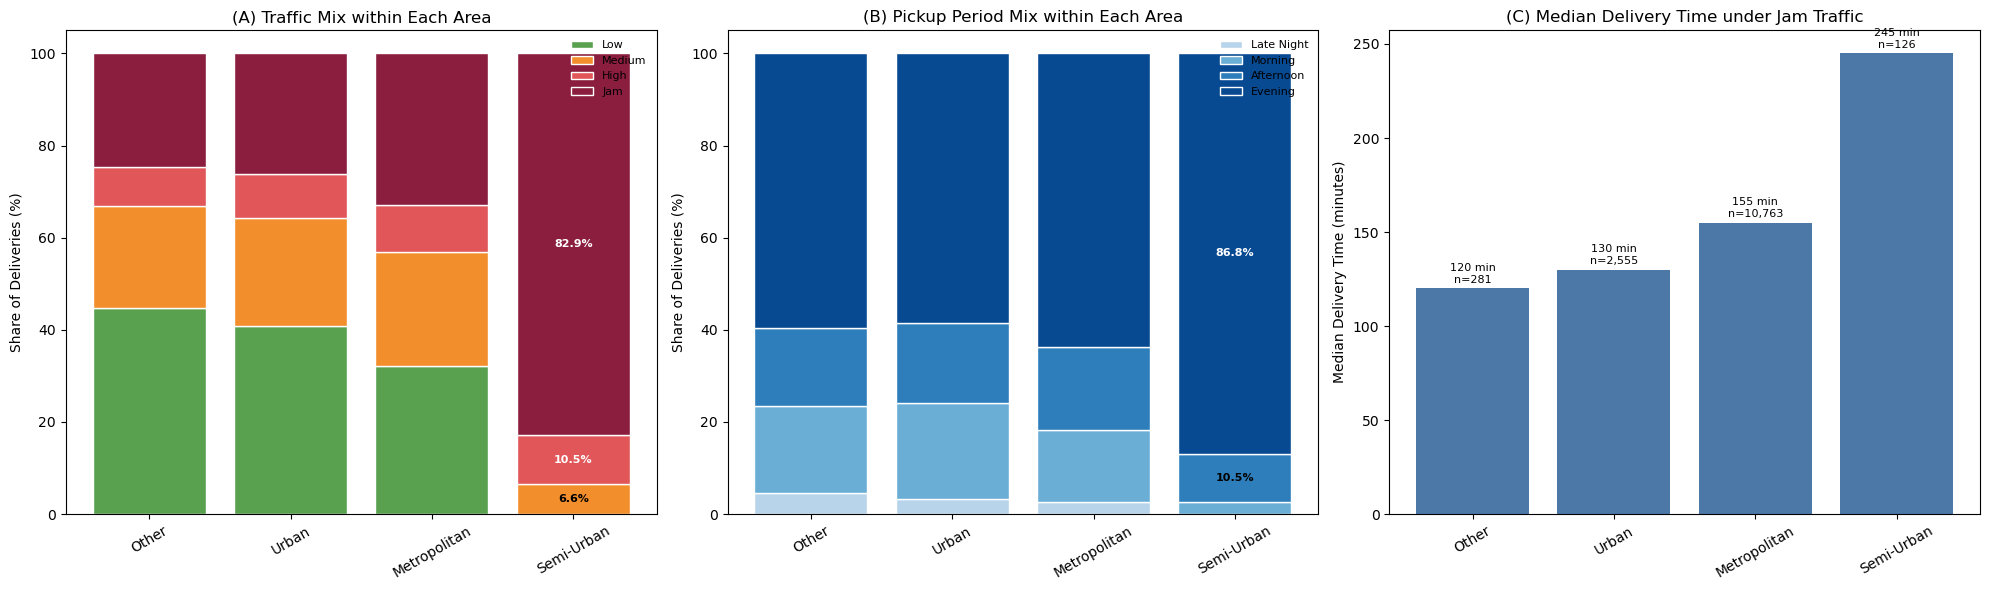

In [6]:
distance_analysis = df.dropna(subset=["Distance_km", "Delivery_Time"])
distance_test = spearmanr(distance_analysis["Distance_km"], distance_analysis["Delivery_Time"])
distance_by_area = (
    distance_analysis.groupby("Area")
    .agg(
        valid_distance_records=("Distance_km", "size"),
        median_distance_km=("Distance_km", "median"),
        median_delivery_minutes=("Delivery_Time", "median"),
    )
    .sort_values("median_distance_km", ascending=False)
)

area_traffic_mix = pd.crosstab(df["Area"], df["Traffic"], normalize="index").mul(100)
area_period_mix = pd.crosstab(df["Area"], df["Pickup_Period"], normalize="index").mul(100)
jam_area_comparison = (
    df.loc[df["Traffic"].eq("Jam")]
    .groupby("Area")
    .agg(sample_size=("Delivery_Time", "size"), median_minutes=("Delivery_Time", "median"))
    .sort_values("median_minutes", ascending=False)
)

print(f"Distance vs. Delivery Time — Spearman rho: {distance_test.statistic:.3f}, p-value < 0.001")
display(distance_by_area.round(2))

# Visualize composition and compare Areas under the same Jam condition.
area_order = ["Other", "Urban", "Metropolitan", "Semi-Urban"]
traffic_order = ["Low", "Medium", "High", "Jam"]
period_order = ["Late Night", "Morning", "Afternoon", "Evening"]
traffic_plot = area_traffic_mix.reindex(index=area_order, columns=traffic_order, fill_value=0)
period_plot = area_period_mix.reindex(index=area_order, columns=period_order, fill_value=0)
jam_plot = jam_area_comparison.reindex(area_order)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

bottom = np.zeros(len(traffic_plot))
traffic_colors = {"Low": "#59A14F", "Medium": "#F28E2B", "High": "#E15759", "Jam": "#8B1E3F"}
for level in traffic_order:
    axes[0].bar(traffic_plot.index, traffic_plot[level], bottom=bottom, label=level, color=traffic_colors[level], edgecolor="white")
    bottom += traffic_plot[level].to_numpy()
axes[0].set_title("(A) Traffic Mix within Each Area")
axes[0].set_ylabel("Share of Deliveries (%)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(frameon=False, fontsize=8)
semi_position = area_order.index("Semi-Urban")
semi_bottom = 0
for level in traffic_order:
    value = traffic_plot.loc["Semi-Urban", level]
    if value >= 5:
        axes[0].text(semi_position, semi_bottom + value / 2, f"{value:.1f}%", ha="center", va="center", color="white" if level in ["High", "Jam"] else "black", fontsize=8, fontweight="bold")
    semi_bottom += value

bottom = np.zeros(len(period_plot))
period_colors = dict(zip(period_order, plt.cm.Blues(np.linspace(0.3, 0.9, len(period_order)))))
for level in period_order:
    axes[1].bar(period_plot.index, period_plot[level], bottom=bottom, label=level, color=period_colors[level], edgecolor="white")
    bottom += period_plot[level].to_numpy()
axes[1].set_title("(B) Pickup Period Mix within Each Area")
axes[1].set_ylabel("Share of Deliveries (%)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(frameon=False, fontsize=8)
semi_bottom = 0
for level in period_order:
    value = period_plot.loc["Semi-Urban", level]
    if value >= 5:
        axes[1].text(semi_position, semi_bottom + value / 2, f"{value:.1f}%", ha="center", va="center", color="white" if level == "Evening" else "black", fontsize=8, fontweight="bold")
    semi_bottom += value

bars = axes[2].bar(jam_plot.index, jam_plot["median_minutes"], color="#4C78A8")
axes[2].set_title("(C) Median Delivery Time under Jam Traffic")
axes[2].set_ylabel("Median Delivery Time (minutes)")
axes[2].tick_params(axis="x", rotation=30)
for bar, sample_size in zip(bars, jam_plot["sample_size"]):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3, f"{bar.get_height():.0f} min\nn={int(sample_size):,}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

### 7.3 Section conclusion

**Observation:** Among the 138 records with valid distance, the Semi-Urban median distance is about 12.5 km. Other Areas are about 7.8-9.3 km. Across all records, Distance has a positive but not strong relationship with Delivery Time (Spearman rho is about 0.29). Among all 152 Semi-Urban records, 82.9% have Jam traffic, none have Low Traffic, and 86.8% occur in the Evening.

**Further comparison:** Even when only Jam records are compared, Semi-Urban still has a median delivery time of 245 minutes (n = 126). This is higher than Metropolitan at 155 minutes (n = 10,763), Urban at 130 minutes (n = 2,555), and Other at 120 minutes (n = 281).

**Interpretation:** Semi-Urban routes are slightly longer, and its records are concentrated in Jam traffic and Evening pickup periods. These are useful clues. However, a large Area gap remains under the same Jam condition. Distance, Traffic mix, and Pickup Period cannot explain the result by themselves.

**Conclusion:** The evidence supports making Semi-Urban the first Area to investigate. It does not support saying that Traffic or Evening causes the longer delivery time. The next step is to collect route design, pickup waiting time, agent availability, order volume, and dispatch rule data to check whether an unobserved local process explains the gap.

## 8. Multivariable Analysis

### 8.1 What does this step need to answer?

The previous section found that Distance, Traffic mix, and Pickup Period cannot fully explain the Semi-Urban gap. It also identified missing data that may matter: route design, pickup waiting time, agent availability, order volume, and dispatch rules. The current static dataset does not include these fields, so this section **cannot directly test the missing local processes**.

Before collecting new data, the multivariable model provides one final stability check:

1. After including the observed Area, Traffic, Pickup Period, Distance, Weather, and Category fields, does the Semi-Urban gap remain?
2. Which observed relationships are stable, and which change when the model changes?
3. Is the remaining unexplained gap large enough to support collecting route and capacity data for Semi-Urban first?

If the Semi-Urban gap becomes much smaller, the observed group mix may explain the problem. If the gap remains large, the missing process data should become the next focus. This still does not prove that the missing factors are the cause.

### 8.2 Model setup

The analysis uses a simple linear regression with Area, Traffic, Pickup Period, Distance, Weather, and Category. HC3 robust standard errors reduce the effect of unequal variance on confidence intervals. The reference groups are Other Area, Low Traffic, Morning, Sunny, and Grocery. Each coefficient is the average minute difference from its reference group after including the other observed factors. It is an adjusted relationship, not a causal effect.

### 8.3 How to read the output and charts

- The coefficient table shows the estimated minute difference, HC3 standard error, 95% confidence interval, and p-value.
- The left chart shows the main adjusted coefficients and 95% confidence intervals. Positive Area, Traffic, and Pickup Period values mean longer delivery time than the reference group. The original Distance coefficient is per 1 km. The chart shows the value per 5 km to make it easier to read, which is about 11 minutes.
- The middle chart compares Pickup Period coefficients in a model without Traffic and a model with Traffic. This checks whether the time-period result is stable.
- The right chart shows the actual sample size for each Traffic and Pickup Period combination. A blank or zero means the combination is missing, so the model cannot reliably separate the two factors.

Model records: 39,997
R-squared: 0.482; adjusted R-squared: 0.482


,term,coefficient,robust_se,ci_low,ci_high,p_value
1,Distance_km,2.20,0.04,2.12,2.29,< 0.001
2,Area_Urban,2.85,1.21,0.47,5.23,0.019
3,Area_Metropolitan,17.47,1.17,15.18,19.76,< 0.001
4,Area_Semi-Urban,102.04,3.03,96.11,107.98,< 0.001
5,Traffic_Medium,21.85,0.60,20.66,23.03,< 0.001
6,Traffic_High,36.11,0.81,34.53,37.69,< 0.001
7,Traffic_Jam,39.30,0.55,38.22,40.38,< 0.001
8,Pickup_Period_Late Night,-8.14,1.19,-10.47,-5.82,< 0.001
9,Pickup_Period_Afternoon,-8.57,0.81,-10.16,-6.98,< 0.001
10,Pickup_Period_Evening,-7.87,0.67,-9.18,-6.57,< 0.001


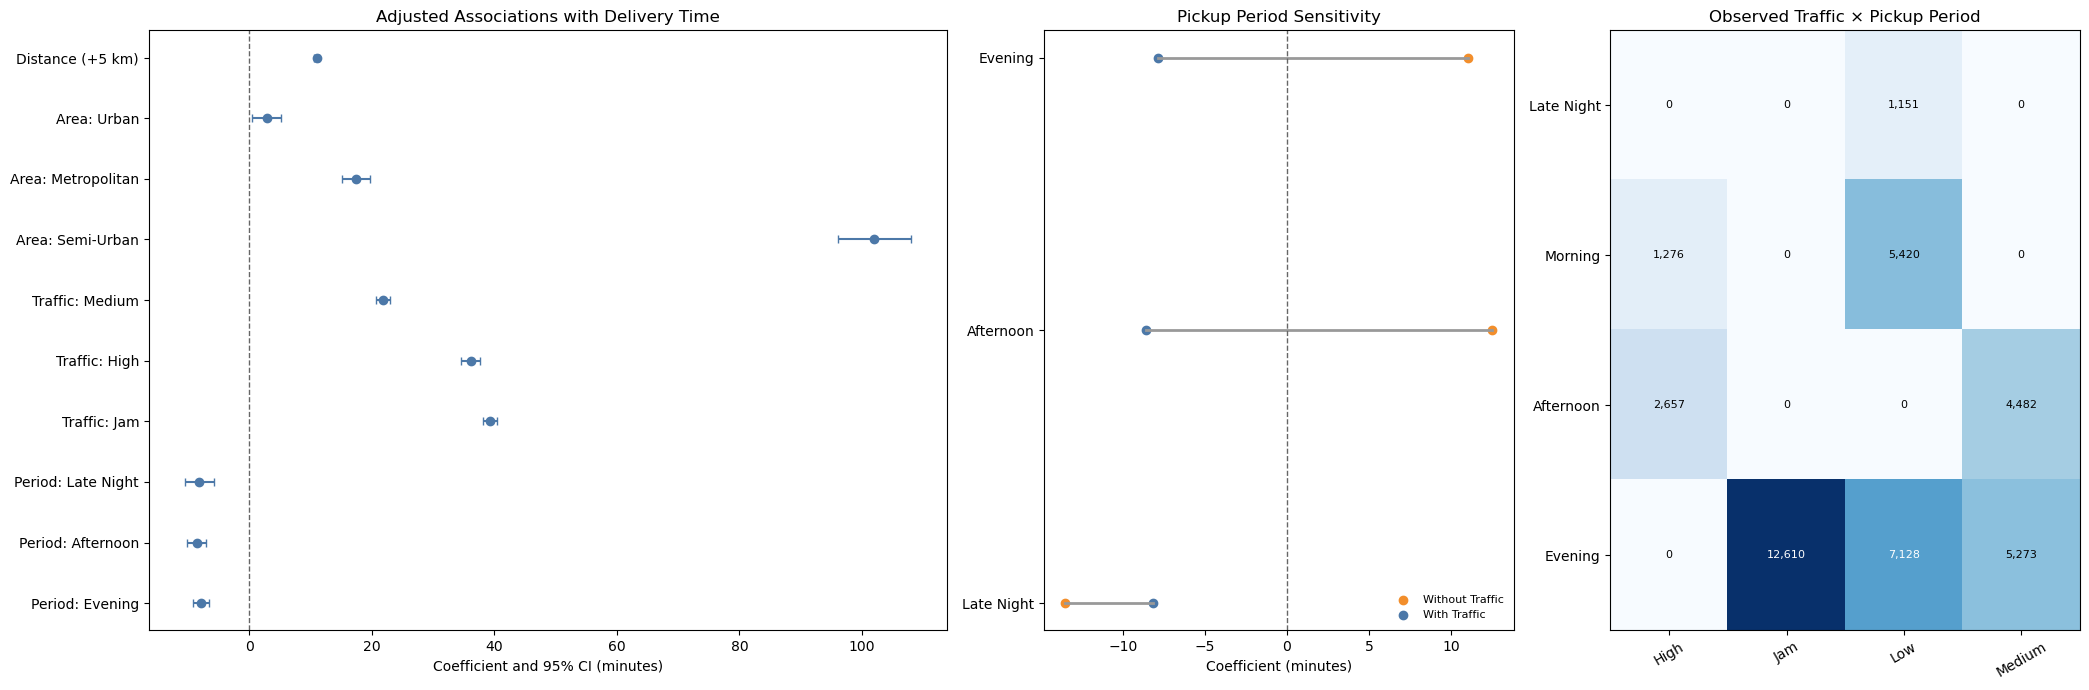

In [7]:
def fit_ols_hc3(model_data, predictors, categorical_orders):
    # Fit OLS and calculate HC3 heteroskedasticity-robust standard errors.
    categorical_columns = [column for column in categorical_orders if column in predictors]
    prepared = model_data[["Delivery_Time"] + predictors].copy()
    for column in categorical_columns:
        prepared[column] = pd.Categorical(
            prepared[column], categories=categorical_orders[column]
        )

    design = pd.get_dummies(
        prepared[predictors],
        columns=categorical_columns,
        drop_first=True,
        dtype=float,
    )
    design.insert(0, "Intercept", 1.0)
    x = design.to_numpy(dtype=float)
    y = prepared["Delivery_Time"].to_numpy(dtype=float)

    coefficients = np.linalg.lstsq(x, y, rcond=None)[0]
    fitted = x @ coefficients
    residuals = y - fitted
    xtx_inverse = np.linalg.pinv(x.T @ x)
    leverage = np.einsum("ij,jk,ik->i", x, xtx_inverse, x)
    adjusted_residuals = residuals / (1 - leverage)
    meat = x.T @ ((adjusted_residuals ** 2)[:, None] * x)
    covariance = xtx_inverse @ meat @ xtx_inverse
    robust_se = np.sqrt(np.diag(covariance))
    p_values = 2 * norm.sf(np.abs(coefficients / robust_se))

    total_ss = ((y - y.mean()) ** 2).sum()
    residual_ss = (residuals ** 2).sum()
    r_squared = 1 - residual_ss / total_ss
    adjusted_r_squared = 1 - (1 - r_squared) * (len(y) - 1) / (len(y) - len(coefficients))

    results = pd.DataFrame({
        "term": design.columns,
        "coefficient": coefficients,
        "robust_se": robust_se,
        "ci_low": coefficients - 1.96 * robust_se,
        "ci_high": coefficients + 1.96 * robust_se,
        "p_value": p_values,
    })
    metrics = {"records": len(y), "r_squared": r_squared, "adjusted_r_squared": adjusted_r_squared}
    return results, metrics


model_columns = [
    "Delivery_Time", "Distance_km", "Area", "Traffic",
    "Pickup_Period", "Weather", "Category",
]
model_data = df[model_columns].dropna().copy()
category_orders = {
    "Area": ["Other", "Urban", "Metropolitan", "Semi-Urban"],
    "Traffic": ["Low", "Medium", "High", "Jam"],
    "Pickup_Period": ["Morning", "Late Night", "Afternoon", "Evening"],
    "Weather": ["Sunny", "Windy", "Sandstorms", "Stormy", "Fog", "Cloudy"],
    "Category": ["Grocery"] + sorted(
        category for category in model_data["Category"].unique() if category != "Grocery"
    ),
}
full_predictors = ["Distance_km", "Area", "Traffic", "Pickup_Period", "Weather", "Category"]
full_results, full_metrics = fit_ols_hc3(model_data, full_predictors, category_orders)
no_traffic_results, _ = fit_ols_hc3(
    model_data, [column for column in full_predictors if column != "Traffic"], category_orders
)

key_terms = [
    "Distance_km", "Area_Urban", "Area_Metropolitan", "Area_Semi-Urban",
    "Traffic_Medium", "Traffic_High", "Traffic_Jam",
    "Pickup_Period_Late Night", "Pickup_Period_Afternoon", "Pickup_Period_Evening",
]
key_coefficients = full_results.loc[full_results["term"].isin(key_terms)].copy()
key_coefficients["p_value"] = key_coefficients["p_value"].map(
    lambda value: "< 0.001" if value < 0.001 else f"{value:.3f}"
)

period_terms = ["Pickup_Period_Late Night", "Pickup_Period_Afternoon", "Pickup_Period_Evening"]
period_sensitivity = (
    no_traffic_results.loc[no_traffic_results["term"].isin(period_terms), ["term", "coefficient"]]
    .rename(columns={"coefficient": "without_traffic"})
    .merge(
        full_results.loc[full_results["term"].isin(period_terms), ["term", "coefficient"]]
        .rename(columns={"coefficient": "with_traffic"}),
        on="term",
    )
)
traffic_period_overlap = pd.crosstab(model_data["Pickup_Period"], model_data["Traffic"])

print(f"Model records: {full_metrics['records']:,}")
print(f"R-squared: {full_metrics['r_squared']:.3f}; adjusted R-squared: {full_metrics['adjusted_r_squared']:.3f}")
display(key_coefficients.round(2))

# Plot adjusted coefficients, period sensitivity, and observed overlap.
coefficient_labels = {
    "Distance_km": "Distance (+5 km)",
    "Area_Urban": "Area: Urban",
    "Area_Metropolitan": "Area: Metropolitan",
    "Area_Semi-Urban": "Area: Semi-Urban",
    "Traffic_Medium": "Traffic: Medium",
    "Traffic_High": "Traffic: High",
    "Traffic_Jam": "Traffic: Jam",
    "Pickup_Period_Late Night": "Period: Late Night",
    "Pickup_Period_Afternoon": "Period: Afternoon",
    "Pickup_Period_Evening": "Period: Evening",
}
coefficient_plot = full_results.set_index("term").loc[key_terms].copy()
coefficient_plot.loc["Distance_km", ["coefficient", "ci_low", "ci_high"]] *= 5
coefficient_plot["label"] = [coefficient_labels[term] for term in coefficient_plot.index]
coefficient_plot = coefficient_plot.iloc[::-1]

fig, axes = plt.subplots(1, 3, figsize=(21, 7), gridspec_kw={"width_ratios": [1.7, 1, 1]})
y_positions = np.arange(len(coefficient_plot))
axes[0].errorbar(
    coefficient_plot["coefficient"],
    y_positions,
    xerr=[
        coefficient_plot["coefficient"] - coefficient_plot["ci_low"],
        coefficient_plot["ci_high"] - coefficient_plot["coefficient"],
    ],
    fmt="o",
    color="#4C78A8",
    ecolor="#4C78A8",
    capsize=3,
)
axes[0].axvline(0, color="#666666", linestyle="--", linewidth=1)
axes[0].set_yticks(y_positions, coefficient_plot["label"])
axes[0].set_title("Adjusted Associations with Delivery Time")
axes[0].set_xlabel("Coefficient and 95% CI (minutes)")

period_labels = {
    "Pickup_Period_Late Night": "Late Night",
    "Pickup_Period_Afternoon": "Afternoon",
    "Pickup_Period_Evening": "Evening",
}
for position, row in period_sensitivity.reset_index(drop=True).iterrows():
    axes[1].plot([row["without_traffic"], row["with_traffic"]], [position, position], color="#999999", linewidth=2)
    axes[1].scatter(row["without_traffic"], position, color="#F28E2B", label="Without Traffic" if position == 0 else None)
    axes[1].scatter(row["with_traffic"], position, color="#4C78A8", label="With Traffic" if position == 0 else None)
axes[1].axvline(0, color="#666666", linestyle="--", linewidth=1)
axes[1].set_yticks(range(len(period_sensitivity)), [period_labels[term] for term in period_sensitivity["term"]])
axes[1].set_title("Pickup Period Sensitivity")
axes[1].set_xlabel("Coefficient (minutes)")
axes[1].legend(frameon=False, fontsize=8)

overlap_values = traffic_period_overlap.to_numpy()
image = axes[2].imshow(overlap_values, cmap="Blues", aspect="auto")
axes[2].set_xticks(range(len(traffic_period_overlap.columns)), traffic_period_overlap.columns, rotation=30)
axes[2].set_yticks(range(len(traffic_period_overlap.index)), traffic_period_overlap.index)
axes[2].set_title("Observed Traffic × Pickup Period")
for row_index in range(overlap_values.shape[0]):
    for column_index in range(overlap_values.shape[1]):
        value = overlap_values[row_index, column_index]
        text_color = "white" if value > overlap_values.max() * 0.55 else "black"
        axes[2].text(column_index, row_index, f"{value:,}", ha="center", va="center", color=text_color, fontsize=8)

plt.tight_layout()
plt.show()

### 8.4 Results and section conclusion

**Observation:** The model uses 39,997 complete records and explains about 48.2% of the variation in Delivery Time. After including the other observed factors:

- Semi-Urban is still about **102 minutes** higher than Other. The 95% confidence interval is about 96-108 minutes.
- Jam is about **39 minutes** higher than Low Traffic. Each additional 1 km is linked to about **2.2 more minutes**; the chart shows about 11 minutes per 5 km.
- Non-Grocery categories are about 103-106 minutes higher than Grocery. This supports the idea that Grocery may use a different delivery process.
- Pickup Period changes direction after Traffic is added. Jam appears only in Evening, and Late Night appears only in Low Traffic. The data does not have enough overlap to separate Traffic from Pickup Period reliably.

**Interpretation:** The Semi-Urban gap remains large after including the current fields. The mix of Distance, Traffic, Pickup Period, Weather, and Category does not explain the full Area difference. However, the Area coefficient may also capture route design, pickup waiting, agent availability, order volume, dispatch rules, or other missing factors. It does not mean that Semi-Urban itself causes 102 extra minutes. The unstable Pickup Period result also means that the raw group average should not be turned directly into a staffing decision.

**Conclusion:** Semi-Urban should be the first Area for the next operations review. The next section explains the data to collect, recommended actions, and analysis limits.

## 9. Recommendations and Limitations

### 9.1 From evidence to decision

| Evidence | What it means | Decision impact |
|---|---|---|
| No SLA or promised ETA | The analysis can measure delivery time but cannot label a delivery as late | Use Delivery Time, median, P75, and long-duration rate to measure change |
| Semi-Urban median is 245 minutes and 94.7% are above 160 minutes | The problem is concentrated and large enough to matter | Make Semi-Urban the first Area to diagnose |
| Distance is slightly longer, and Jam and Evening shares are high | These factors may be related | Keep them as clues, but do not call them causes |
| Semi-Urban remains much slower under the same Jam condition | Traffic mix does not explain the Area gap | Review local processes and missing factors |
| Semi-Urban remains about 102 minutes higher in the multivariable model | Current fields do not explain the full gap | Collect route, waiting, capacity, and dispatch data first |
| Pickup Period coefficients change when Traffic is added | The time-period result is not stable | Do not change staffing from raw time-period averages alone |

### 9.2 Recommendations

#### 1. Start with a focused Semi-Urban process review

Do not increase resources across the whole network or change Semi-Urban order volume or delivery assignment yet. First, collect better process records for naturally occurring Semi-Urban deliveries and keep other Areas as comparison groups. Split total delivery time into steps that the team can act on: waiting for assignment, travel to pickup, pickup waiting, delivery travel, and handoff. If the sample is still too small, extend the observation period.

#### 2. Add data that can separate possible causes

| Possible issue | Data needed | Decision supported |
|---|---|---|
| Route bottleneck | route ID, planned and actual path, travel time by segment | Change routes or delivery coverage |
| Pickup delay | store arrival time, ready time, pickup completion time | Improve preparation or pickup handoff |
| Capacity shortage | order volume by period, active agents, agent utilization | Add or move capacity |
| Dispatch issue | assignment time, dispatch rules, batch size, reassignment | Change dispatch logic |
| Service and cost | promised ETA, completion time, cost per delivery | Improve time, on-time rate, and cost together |

#### 3. Check whether Grocery uses a different process

Grocery delivery times are very different from other categories. If Grocery uses a different fulfillment or delivery process, future analysis and models should separate it so it does not change the comparison baseline.

#### 4. Choose the improvement only after finding the bottleneck

If the gap mainly comes from travel time, test a route change. If it comes from pickup waiting, improve preparation and handoff. If it comes from an orders-to-agents imbalance, adjust staffing. If it comes from assignment delay, test a dispatch rule. This avoids adding capacity everywhere before the problem is understood.

#### 5. Use a small test before wider rollout

Do not change order volume or delivery assignment for the test. Apply a small route, pickup, capacity, or dispatch change to naturally occurring Semi-Urban deliveries that meet the test conditions. Keep similar deliveries without the change as a comparison. Track median Delivery Time, P75, and long-duration rate. If an SLA becomes available, also track on-time rate. Use cost per delivery as a guardrail.

Here, a wider rollout means using a successful change in more similar operations. It does not mean increasing delivery volume. For example:

- Route change: move from a few test routes to other routes with the same bottleneck.
- Pickup change: move from a few Stores to other Stores with long pickup waiting times.
- Capacity change: move from one shift to other shifts with the same orders-to-agents imbalance.
- Dispatch rule: move from a few agents or routes to other deliveries with the same conditions.

Expand the change only if delivery time and long-duration rate improve, cost stays acceptable, and other service metrics do not get worse.

### 9.3 Limitations

- **Data use:** This is a public, static, observational dataset. It cannot prove cause and effect and does not represent Amazon's current operations.
- **Time range:** The data covers only 44 dates from 2022-02-11 to 2022-04-06. It cannot show seasonality or long-term stability.
- **KPI limit:** There is no SLA or promised ETA. The 160-minute cutoff is only an analysis threshold and does not mean late delivery.
- **Sample limit:** Semi-Urban has 152 records. Distance analysis uses 138 of them, and the Jam-only comparison uses 126.
- **Coordinate quality:** Across the full dataset, 3,693 records fail the distance quality rules. Distance results may not represent every delivery.
- **Data overlap:** Jam appears only in Evening, and Late Night appears only in Low Traffic. The model cannot reliably separate Traffic from Pickup Period.
- **Missing process data:** Route, pickup waiting, order volume, agent availability, dispatch, promised ETA, and cost are missing. The Area coefficient may capture these unobserved factors.
- **Model limit:** Linear regression with HC3 standard errors only describes adjusted relationships. It still depends on linearity, independent observations, and the chosen model setup.

### 9.4 Final decision

**What can be decided now:** Make Semi-Urban the first Area for data collection and process diagnosis.

**What cannot be decided now:** Do not claim that Traffic, Evening, low staffing, or route design is the root cause. Do not add capacity across the whole network yet.

**Next decision point:** After collecting and separating Semi-Urban route, waiting, capacity, and dispatch data, choose a low-risk improvement and test it on a small scale before wider rollout.

## Appendix

### A. Why use HC3 robust standard errors?

Standard OLS errors assume that the error variance is similar across records. This dataset has very different group sizes and delivery time distributions. For example, Semi-Urban has only 152 records, while Metropolitan has more than 30,000. Grocery delivery times are also very different from other categories. The equal-variance assumption may not hold.

HC3 allows error variance to differ across records and makes a more careful adjustment for high-leverage observations. This makes standard errors, confidence intervals, and p-values less likely to be too optimistic. HC3 does not change the regression coefficients, predictions, or R-squared. It also does not turn observational data into causal evidence.

HC3 still assumes that records are independent. It cannot handle possible clustering within the same route, city, or date. If route, city, or other group IDs become available, clustered standard errors or a multilevel model should be considered.

### B. Full group statistics

The table below keeps the full sample size, mean, median, IQR, and long-duration rate for Area, Traffic, and Pickup Period. Use it when checking the exact values shown in the charts.

In [8]:
key_group_results = pd.concat(
    {factor: group_summaries[factor] for factor in key_factors},
    names=["factor", "level"],
)
display(key_group_results.round(2))

sample_size  mean_minutes  median_minutes  \
factor        level                                                     
Area          Semi-Urban            152        238.55          245.00   
              Metropolitan        32698        129.70          130.00   
              Urban                9751        109.43          105.00   
              Other                1138        104.46          100.00   
Traffic       Jam                 13725        147.76          150.00   
              High                 4296        129.42          135.00   
              Medium              10628        126.84          130.00   
              Low                 14999        101.35          100.00   
Pickup_Period Afternoon            7804        125.96          130.00   
              Evening             27355        132.24          130.00   
              Late Night           1259        106.00          105.00   
              Morning              7321         99.62           95.00   

                            q1_minutes  q3_minutes  long_duration_rate  
factor        level                                                     
Area          Semi-Urban        238.75      261.25               94.74  
              Metropolitan       95.00      165.00               25.85  
              Urban              75.00      140.00               13.92  
              Other              75.00      135.00               11.42  
Traffic       Jam               110.00      190.00               41.01  
              High              100.00      160.00               22.84  
              Medium             90.00      160.00               24.05  
              Low                75.00      125.00                6.03  
Pickup_Period Afternoon          90.00      160.00               22.07  
              Evening            95.00      170.00               28.72  
              Late Night         80.00      130.00                9.77  
              Morning            75.00      125.00                5.25